In [47]:
import numpy as np
import matplotlib.pyplot as plt

def plot_image_and_spectrum_numpy(image, title):
    """
    Plots an image and its 2D Fourier Transform magnitude spectrum using NumPy.
    """
    plt.figure(figsize=(12, 6))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'Original Image: {title}')
    plt.axis('off')

    # Compute 2D DFT using NumPy
    # 1. Ensure image data type is float for FFT
    f = np.float64(image) # Use float64 for better precision with FFT

    # 2. Compute the 2D FFT
    # np.fft.fft2 returns complex numbers directly
    dft = np.fft.fft2(f)

    # 3. Shift the zero-frequency component to the center
    # This is important for visualization, as low frequencies are usually at corners without shift
    dft_shift = np.fft.fftshift(dft)

    # 4. Compute the magnitude spectrum (logarithmic scale for better visualization)
    # np.abs calculates the magnitude of complex numbers (sqrt(real^2 + imag^2))
    magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1) # +1 to avoid log(0)

    # Fourier Spectrum
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title(f'Magnitude Spectrum (Log Scale) of {title}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [114]:
def FFT(image):
    f = np.float64(image) 
    dft = np.fft.fft2(f)
    dft_shift = np.fft.fftshift(dft)

    # np.abs calculates the magnitude of complex numbers (sqrt(real^2 + imag^2))
    magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1) # +1 to avoid log(0)
    return dft_shift

def IFFT(dft):
    f = np.fft.ifftshift(dft)
    f = np.fft.ifft2(f)
    f =np.clip(np.abs(f), 0, 255).astype(np.uint8)
    return f

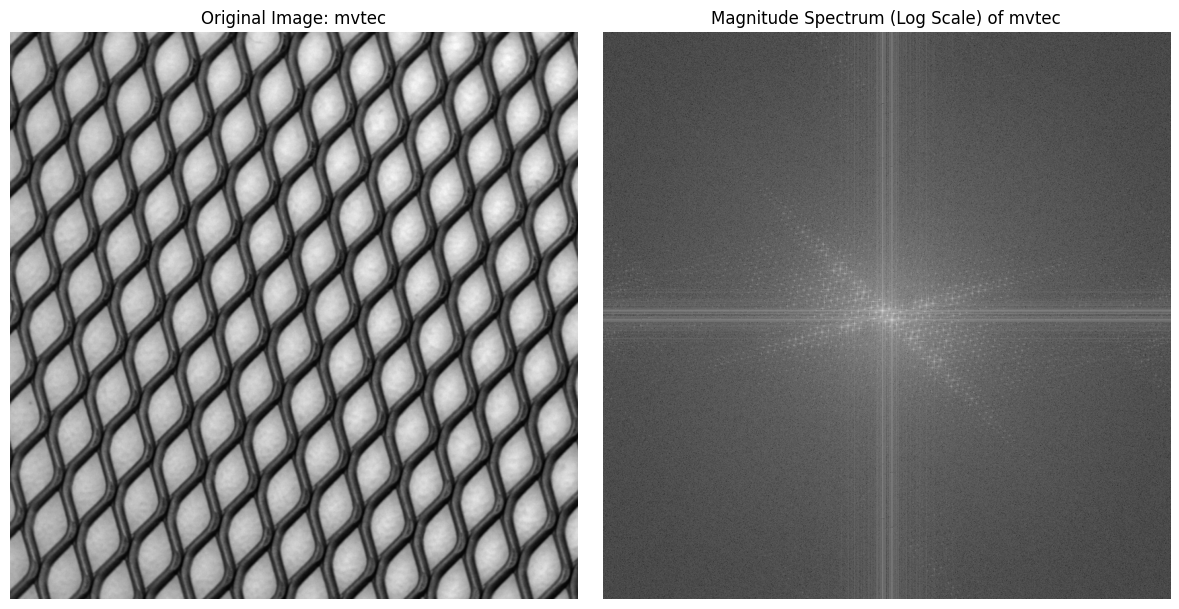

In [115]:
import PIL.Image as Image
image = np.array(Image.open("Datasets/MvTec/good/011.png"))
# image[50:100,700:800] =0
plot_image_and_spectrum_numpy(image, "mvtec")

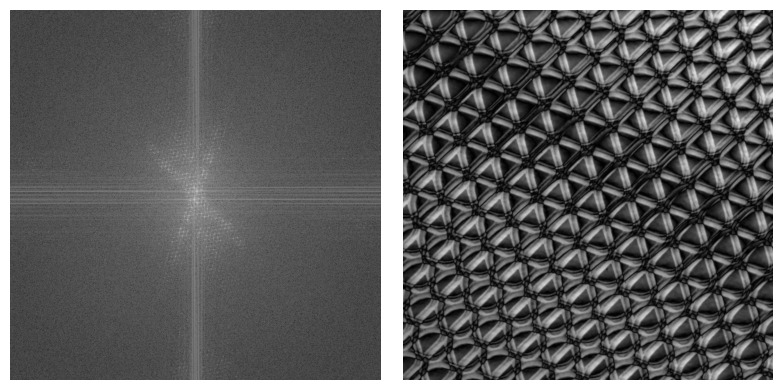

In [125]:
image1, image2 = np.array([Image.open("Datasets/MvTec/good/011.png"), Image.open("Datasets/MvTec/good/001.png")])
diff = FFT(image1) - FFT(image2)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(20 * np.log(np.abs(FFT(image2).real) + 1), cmap = 'gray')
# 20 * np.log(np.abs(FFT(image2).real) + 1)
plt.subplot(1, 2, 2)
# print(FFT(image1))
plt.imshow(IFFT(diff), cmap='gray')
plt.axis('off')
plt.tight_layout()

plt.show()

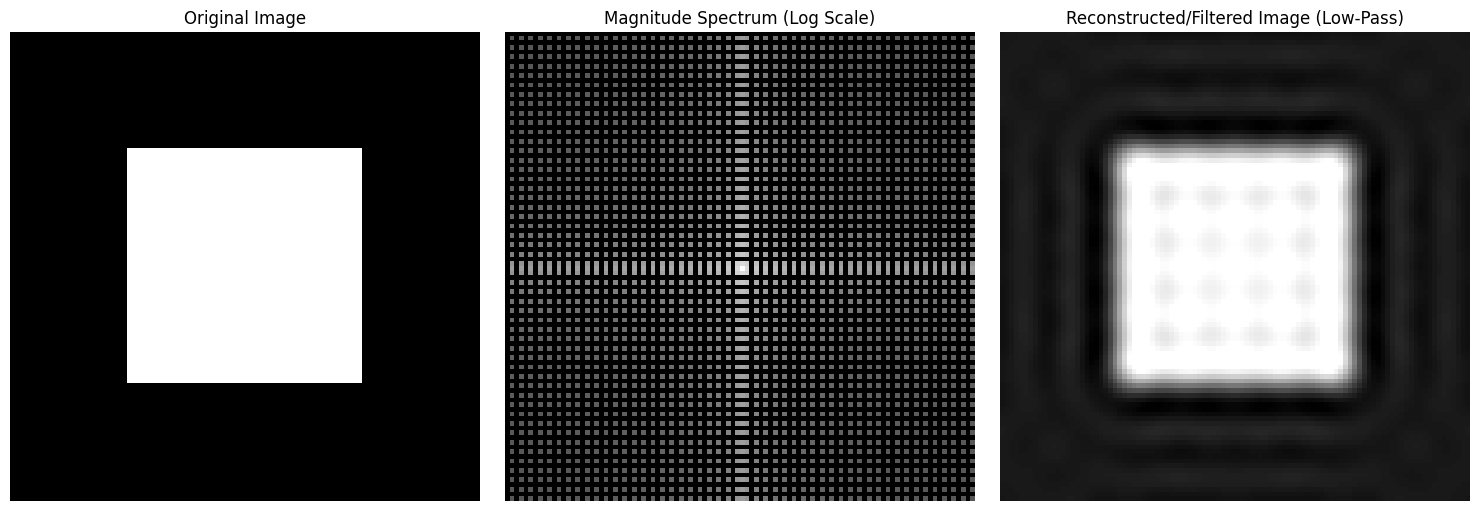

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Create an example image (e.g., a square) ---
original_image = np.full((100, 100), 128, dtype=np.uint8)
original_image[25:75, 25:75] = 255 # A white square on a gray background

# Display original image
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# --- 2. Perform Forward FFT ---
# Ensure float type for FFT
f_transform = np.fft.fft2(np.float64(original_image))

# Shift the zero-frequency component to the center for visualization (optional for IFFT, but good practice)
f_transform_shifted = np.fft.fftshift(f_transform)

# Display Magnitude Spectrum
magnitude_spectrum = 20 * np.log(np.abs(f_transform_shifted) + 1)
plt.subplot(1, 3, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum (Log Scale)')
plt.axis('off')

# --- 3. (Optional) Modify the Fourier Spectrum ---
# Example: Simple Low-Pass Filter (Blurring)
# We'll create a mask to keep only the central (low) frequencies
rows, cols = original_image.shape
crow, ccol = rows // 2, cols // 2
mask_radius = 10 # Adjust this to control the amount of blurring

# Create a circular mask for low-pass filtering
mask = np.zeros((rows, cols), dtype=np.uint8)
y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
mask_circle = x*x + y*y <= mask_radius*mask_radius
mask[mask_circle] = 1

# Apply the mask to the *shifted* Fourier transform
# Note: The mask should be applied to the complex-valued f_transform_shifted
f_transform_filtered_shifted = f_transform_shifted * mask

# --- 4. Perform Inverse FFT ---
# Shift the zero-frequency component back to the corner before IFFT
# This is crucial for np.fft.ifft2 to work correctly
f_transform_filtered = np.fft.ifftshift(f_transform_filtered_shifted)

# Apply Inverse FFT
# The output is complex, so take the real part (imaginary part should be very small)
reconstructed_image = np.fft.ifft2(f_transform_filtered)
reconstructed_image = np.abs(reconstructed_image) # Take absolute value as there might be small imaginary components due to floating point precision

# Normalize and convert to uint8 for display (values can be outside 0-255 after IFFT)
reconstructed_image = np.clip(reconstructed_image, 0, 255).astype(np.uint8)

# Display Reconstructed/Filtered Image
plt.subplot(1, 3, 3)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed/Filtered Image (Low-Pass)')
plt.axis('off')

plt.tight_layout()
plt.show()

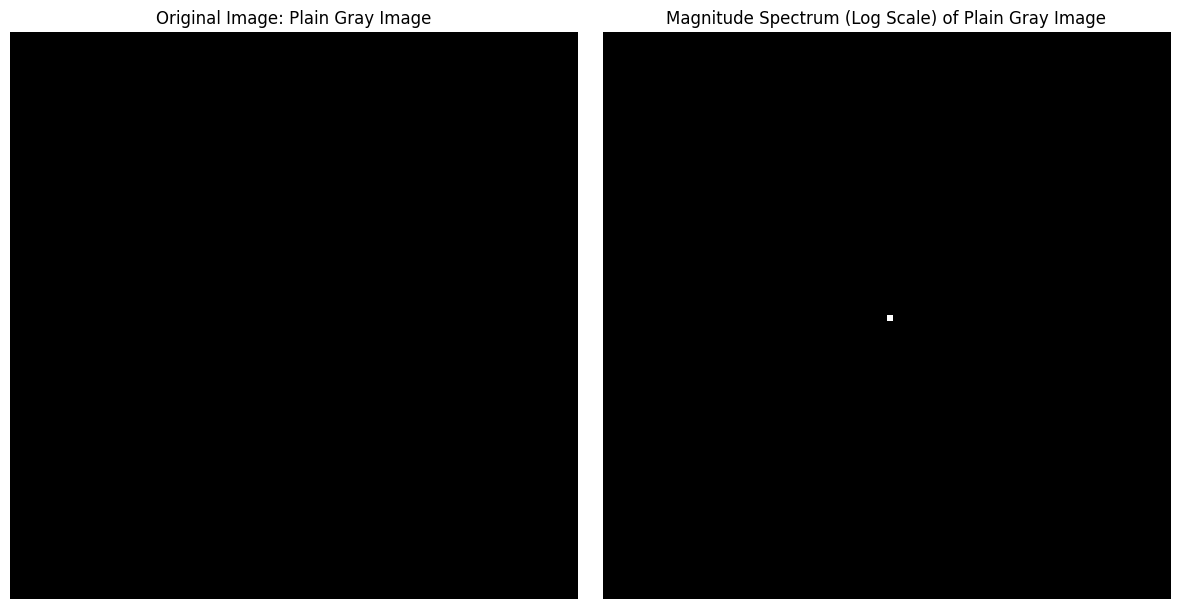

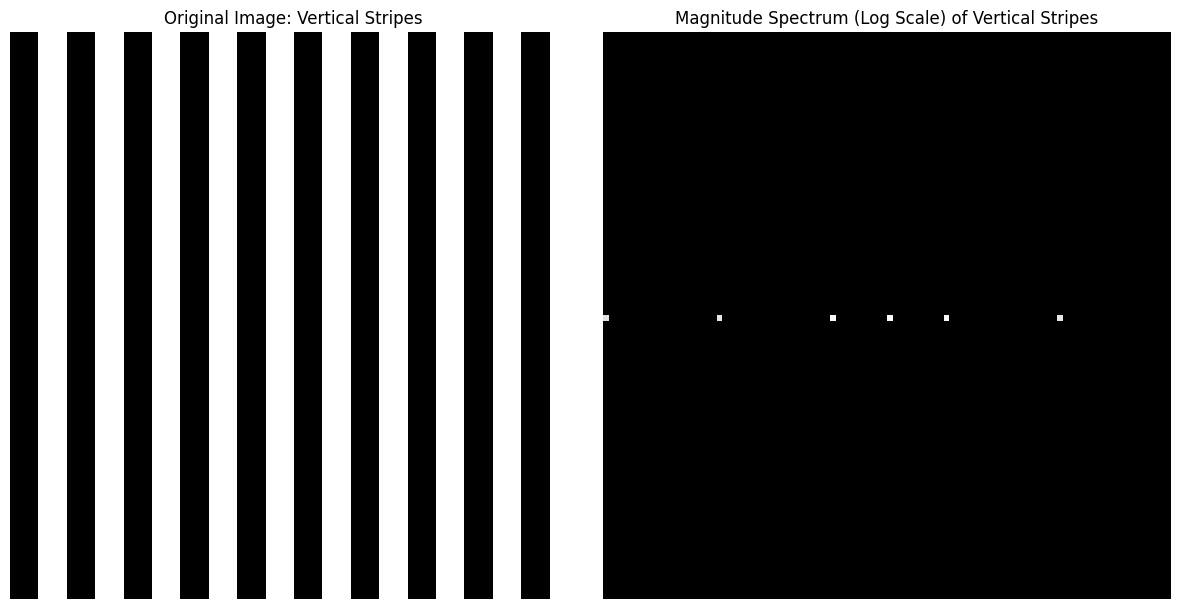

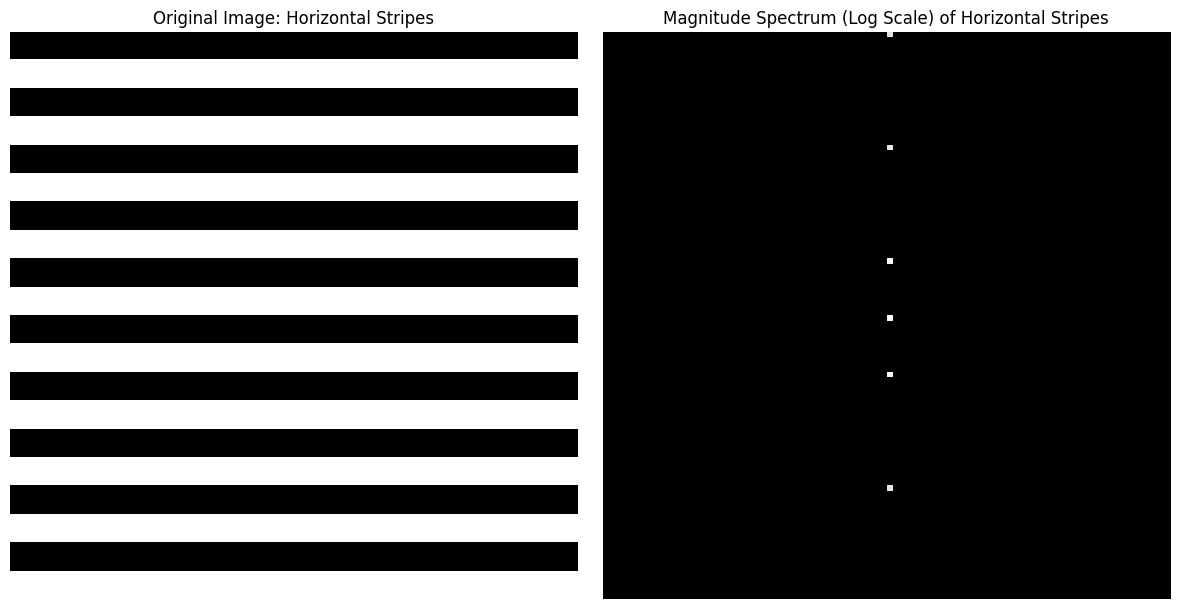

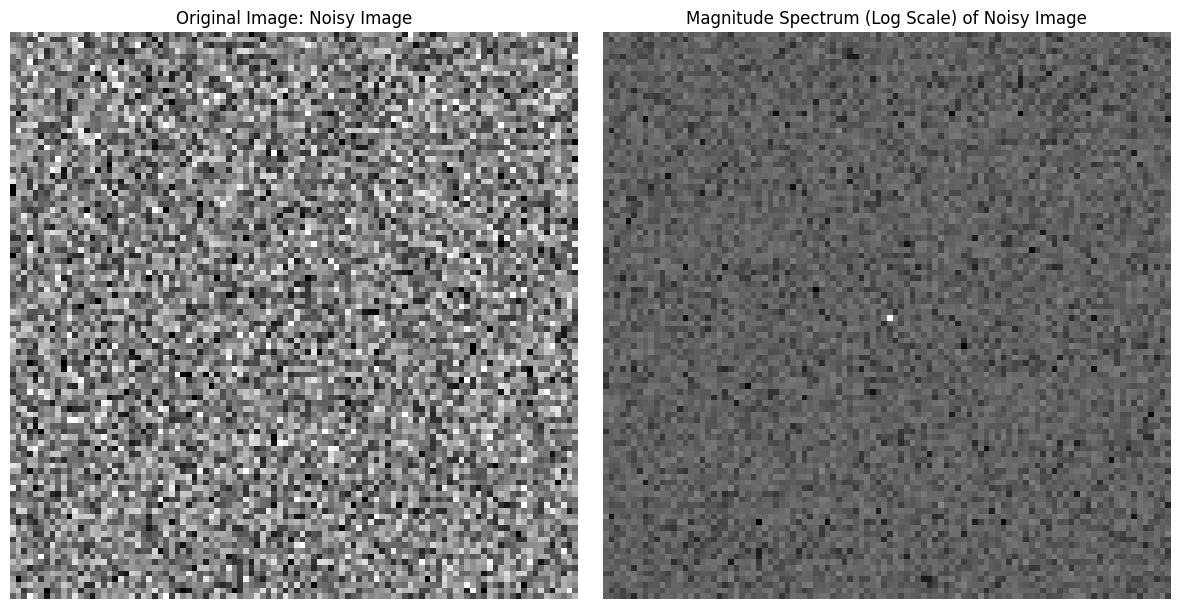

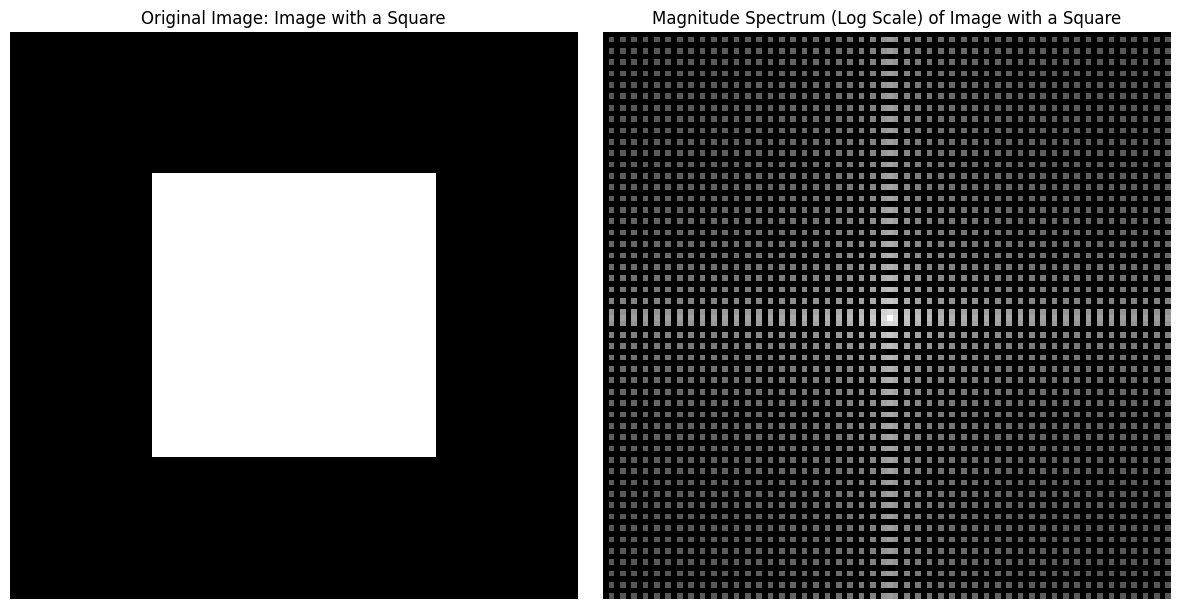

In [7]:

# --- 1. Plain (Uniform) Image ---
plain_image = np.full((100, 100), 200, dtype=np.uint8) # 100x100 gray image
plot_image_and_spectrum_numpy(plain_image, "Plain Gray Image")

# --- 2. Image with Vertical Stripes ---
striped_image_vertical = np.zeros((100, 100), dtype=np.uint8)
# Create vertical stripes: alternating black (0) and white (255) columns
for i in range(100):
    if i % 10 < 5: # 5 pixels black, 5 pixels white
        striped_image_vertical[:, i] = 0 # Black
    else:
        striped_image_vertical[:, i] = 255 # White
plot_image_and_spectrum_numpy(striped_image_vertical, "Vertical Stripes")

# --- 3. Image with Horizontal Stripes ---
striped_image_horizontal = np.zeros((100, 100), dtype=np.uint8)
# Create horizontal stripes: alternating black (0) and white (255) rows
for i in range(100):
    if i % 10 < 5: # 5 pixels black, 5 pixels white
        striped_image_horizontal[i, :] = 0 # Black
    else:
        striped_image_horizontal[i, :] = 255 # White
plot_image_and_spectrum_numpy(striped_image_horizontal, "Horizontal Stripes")

# --- 4. Noisy Image ---
# Create a plain gray image and add random Gaussian noise
noisy_image = np.full((100, 100), 128, dtype=np.float64) # Use float64 here for noise addition
noise = np.random.normal(0, 50, (100, 100)) # Mean 0, Std Dev 50
noisy_image = noisy_image + noise
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8) # Clip to valid pixel range
plot_image_and_spectrum_numpy(noisy_image, "Noisy Image")

# --- 5. Image with Mixed Frequencies (e.g., a simple square) ---
square_image = np.full((100, 100), 128, dtype=np.uint8)
square_image[25:75, 25:75] = 255 # Draw a white square in the middle
plot_image_and_spectrum_numpy(square_image, "Image with a Square")